# Lab 11: Grid Localization using Bayes Filter (Real Robot)

### <span style="color:rgb(0,150,0)">It is recommended that you close any heavy-duty applications running on your system while working on this lab.</span>

### <span style="color:rgb(0,150,0)">The notebook only provides skeleton code for you to integrate the Localization class with the Real Robot.</span>

<hr>

In [1]:
%load_ext autoreload
%autoreload 2

import traceback
from notebook_utils import *
from Traj import *
import asyncio
import pathlib
import os
from utils import load_config_params
from localization_extras import Localization

# The imports below will only work if you copied the required ble-related python files 
# into the notebooks directory
from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import numpy as np

# Setup Logger
LOG = get_logger('demo_notebook.log')
LOG.propagate = False

# Init GUI and Commander
gui = GET_GUI()
cmdr = gui.launcher.commander

2026-05-13 21:05:56,896 | INFO     |: Logger demo_notebook.log initialized.


/Users/y1hhnn/.pyenv/versions/FastRobots_ble/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
# Start the plotter
START_PLOTTER()

Traceback (most recent call last):
  File "/Users/y1hhnn/Desktop/ECE4160/FastRobots-sim-release/src/plotter.py", line 252, in closeEvent
    result = QtGui.QMessageBox.question(self,
             ^^^^^^^^^^^^^^^^^
AttributeError: module 'pyqtgraph.Qt.QtGui' has no attribute 'QMessageBox'
QThreadStorage: entry 0 destroyed before end of thread 0x137e5b5c0


In [29]:
STOP_PLOTTER()
STOP_SIM()

2026-04-26 16:36:45,194 | ERROR    |: Plotter is not running
2026-04-26 16:36:45,194 | ERROR    |: Simulator is not running


# The RealRobot class
Define the RealRobot class in the code cell below, based on the documentation and your real robot communication protocol. <br>
This class is used by the **Localization** class to communicate with the real robot. <br>
More specifically, the **Localization** class utilizes the **RealRobot's** member function **perform_observation_loop()** to get the 18 sensor readings and store them in its member variable **obs_range_data**, which is then utilized in the update step.

In [ ]:
from notebooks import ble


class RealRobot():
    """A class to interact with the real robot
    """
    def __init__(self, commander, ble):
        # Load world config
        self.world_config = os.path.join(str(pathlib.Path(os.getcwd()).parent), "config", "world.yaml")
        
        self.config_params = load_config_params(self.world_config)
        
        # Commander to commuincate with the Plotter process
        # Used by the Localization module to plot odom and belief
        self.cmdr = commander

        # ArtemisBLEController to communicate with the Robot
        self.ble = ble
        self.times = []
        self.yaws = []
        self.tof_1_readings = []
        self.tof_2_readings = []

    def log_handler(self, sender, data: bytearray):
        parts = self.ble.bytearray_to_string(data).split("|")
        if len(parts) == 4:
            timestamp = float(parts[0][2:])
            yaw = float(parts[1][3:])
            tof_1 = float(parts[2][3:])
            tof_2 = float(parts[3][3:])
            self.times.append(float(timestamp))
            self.yaws.append(float(yaw))
            self.tof_1_readings.append(float(tof_1))
            self.tof_2_readings.append(float(tof_2))
            print (f"Received log: timestamp={timestamp}, yaw={yaw}, tof_1={tof_1}, tof_2={tof_2}")

    def get_pose(self):
        """Get robot pose based on odometry
        
        Returns:
            current_odom -- Odometry Pose (meters, meters, degrees)
            current_gt   -- Ground Truth Pose (meters, meters, degrees)
        """
        yaw_deg = float(self.yaws[-1]) if len(self.yaws) > 0 else 0.0
        current_odom = np.array([0.0, 0.0, yaw_deg])
        current_gt = np.array([0.0, 0.0, yaw_deg])
        return current_odom, current_gt

    async def perform_observation_loop(self, rot_vel=120):
        """Perform the observation loop behavior on the real robot, where the robot does  
        a 360 degree turn in place while collecting equidistant (in the angular space) sensor
        readings, with the first sensor reading taken at the robot's current heading. 
        The number of sensor readings depends on "observations_count"(=18) defined in world.yaml.
        
        Keyword arguments:
            rot_vel -- (Optional) Angular Velocity for loop (degrees/second)
                        Do not remove this parameter from the function definition, even if you don't use it.
        Returns:
            sensor_ranges   -- A column numpy array of the range values (meters)
            sensor_bearings -- A column numpy array of the bearings at which the sensor readings were taken (degrees)
                               The bearing values are not used in the Localization module, so you may return a empty numpy array
        """
        _ = rot_vel  
        # 1. Clear previous readings
        self.times = []
        self.yaws = []
        self.tof_1_readings = []
        self.tof_2_readings = []

        # 2. Send commands to configure the 360 degree rotation, set mode, and start
        observations_count = 18
        # self.ble.send_command(CMD.SET_MAP_COUNT, str(observations_count))
        self.ble.send_command(CMD.SET_MAP_DEGREES, "365")
        
        self.ble.send_command(CMD.SET_MODE, "5")
        self.ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
        self.ble.send_command(CMD.SET_SAMPLE_RATE, "20")
        self.ble.send_command(CMD.SET_DURATION, "25000")
        self.ble.send_command(CMD.START_RECORD, "")

        await asyncio.sleep(30)

        # 3. Collect sensor readings until the loop is done
        self.ble.start_notify(self.ble.uuid['RX_STRING'], self.log_handler)
        await asyncio.sleep(3)
        self.ble.send_command(CMD.SEND_LOG, "")
        await asyncio.sleep(40)
        self.ble.stop_notify(self.ble.uuid['RX_STRING'])

        # 4. Format the output
        tof_2 = np.array(self.tof_2_readings)
        yaw_unwrapped = np.degrees(np.unwrap(np.radians(self.yaws)))
        yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]

        valid_indices_2 = (tof_2 > 0) & (tof_2 < 6000)
        valid_angles_2 = np.radians(yaw_continuous[valid_indices_2])
        valid_distances_2 = tof_2[valid_indices_2] + 69.85


        if len(valid_distances_2) < observations_count:
            raise RuntimeError(
                f"Insufficient observation samples: tof={len(valid_distances_2)}, expected={observations_count}"
            )

        ranges_in_meters = [reading / 1000.0 for reading in valid_distances_2[:observations_count]]
        sensor_ranges = np.array(ranges_in_meters)[np.newaxis].T
        sensor_bearings = np.array(valid_angles_2[:observations_count])[np.newaxis].T

        print(f"Sensor Ranges (m): {sensor_ranges.flatten()}")
        print(f"Sensor Bearings (rad): {sensor_bearings.flatten()}")

        np.save("sensor_ranges.npy", sensor_ranges)
        np.save("sensor_bearings.npy", sensor_bearings)

        return sensor_ranges, sensor_bearings


In [ ]:
from notebooks import ble


class RealRobot():
    """A class to interact with the real robot
    """
    def __init__(self, commander, ble):
        # Load world config
        self.world_config = os.path.join(str(pathlib.Path(os.getcwd()).parent), "config", "world.yaml")
        
        self.config_params = load_config_params(self.world_config)
        
        # Commander to commuincate with the Plotter process
        # Used by the Localization module to plot odom and belief
        self.cmdr = commander

        # ArtemisBLEController to communicate with the Robot
        self.ble = ble
        self.times = []
        self.yaws = []
        self.tof_1_readings = []
        self.tof_2_readings = []

    def log_handler(self, sender, data: bytearray):
        parts = self.ble.bytearray_to_string(data).split("|")
        if len(parts) == 4:
            timestamp = float(parts[0][2:])
            yaw = float(parts[1][3:])
            tof_1 = float(parts[2][3:])
            tof_2 = float(parts[3][3:])
            self.times.append(float(timestamp))
            self.yaws.append(float(yaw))
            self.tof_1_readings.append(float(tof_1))
            self.tof_2_readings.append(float(tof_2))
            print (f"Received log: timestamp={timestamp}, yaw={yaw}, tof_1={tof_1}, tof_2={tof_2}")

    def get_pose(self):
        """Get robot pose based on odometry
        
        Returns:
            current_odom -- Odometry Pose (meters, meters, degrees)
            current_gt   -- Ground Truth Pose (meters, meters, degrees)
        """
        current_odom = np.array([0.0, 0.0, 0.0])
        current_gt = np.array([0.0, 0.0, 0.0])
        return current_odom, current_gt

    async def perform_observation_loop(self, rot_vel=120):
        """Perform the observation loop behavior on the real robot, where the robot does  
        a 360 degree turn in place while collecting equidistant (in the angular space) sensor
        readings, with the first sensor reading taken at the robot's current heading. 
        The number of sensor readings depends on "observations_count"(=18) defined in world.yaml.
        
        Keyword arguments:
            rot_vel -- (Optional) Angular Velocity for loop (degrees/second)
                        Do not remove this parameter from the function definition, even if you don't use it.
        Returns:
            sensor_ranges   -- A column numpy array of the range values (meters)
            sensor_bearings -- A column numpy array of the bearings at which the sensor readings were taken (degrees)
                               The bearing values are not used in the Localization module, so you may return a empty numpy array
        """
        _ = rot_vel  
        # 1. Clear previous readings
        self.times = []
        self.yaws = []
        self.tof_1_readings = []
        self.tof_2_readings = []
        observations_count = 

        data = np.load("../data/map_0_0.npz")
        self.times = data["times"].tolist()
        self.yaws = data["yaw_values"].tolist()
        self.tof_1_readings = data["tof_1_values"].tolist()
        self.tof_2_readings = data["tof_2_values"].tolist()

        # 4. Format the output
        tof_2 = np.array(self.tof_2_readings)
        yaw_unwrapped = np.degrees(np.unwrap(np.radians(self.yaws)))
        yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]

        valid_indices_2 = (tof_2 > 0) & (tof_2 < 6000)
        valid_angles_2 = np.radians(yaw_continuous[valid_indices_2])
        valid_distances_2 = tof_2[valid_indices_2] + 69.85


        if len(valid_distances_2) < observations_count:
            raise RuntimeError(
                f"Insufficient observation samples: tof={len(valid_distances_2)}, expected={observations_count}"
            )

        ranges_in_meters = [reading / 1000.0 for reading in valid_distances_2[:observations_count]]
        sensor_ranges = np.array(ranges_in_meters)[np.newaxis].T
        sensor_bearings = np.array(valid_angles_2[:observations_count])[np.newaxis].T

        print(f"Sensor Ranges (m): {sensor_ranges.flatten()}")
        print(f"Sensor Bearings (rad): {sensor_bearings.flatten()}")

        return sensor_ranges, sensor_bearings


In [4]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-04-27 17:27:29,019 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-04-27 17:27:29,019 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-04-27 17:27:39,101 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-04-27 17:27:39,101 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-04-27 17:27:40,007 | INFO     |: Connected to c0:42:0c:78:b8:49


In [5]:
# Initialize RealRobot with a Commander object to communicate with the plotter process
# and the ArtemisBLEController object to communicate with the real robot
robot = RealRobot(cmdr, ble)

# Initialize mapper
# Requires a VirtualRobot object as a parameter
mapper = Mapper(robot)

# Initialize your BaseLocalization object
# Requires a RealRobot object and a Mapper object as parameters
loc = Localization(robot, mapper)

## Plot Map
cmdr.plot_map()

2026-04-27 17:27:41,036 | INFO     |:  | Number of observations per grid cell: 18
2026-04-27 17:27:41,036 | INFO     |:  | Precaching Views...


/Users/y1hhnn/Desktop/ECE4160/FastRobots-sim-release/localization.py:150: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(distance_intersections_tt), intersections_tt[np.nanargmin(distance_intersections_tt)]


2026-04-27 17:27:41,971 | INFO     |:  | Precaching Time: 0.934 secs
2026-04-27 17:27:41,972 | INFO     |: Initializing beliefs with a Uniform Distribution
2026-04-27 17:27:41,973 | INFO     |: Uniform Belief with each cell value: 0.00051440329218107


# Run an update step of the Bayes Filter

In [20]:
# Reset Plots
cmdr.reset_plotter()

# cmdr.plot_gt(1.524, 0.9144) # (5 ft, 3 ft in meters)
cmdr.plot_gt(1.524, -0.9144) # (5 ft, -3 ft in meters)
# cmdr.plot_gt(0,0) 
# cmdr.plot_gt(-0.9144,-0.6096) # (-3 ft, -2 ft in meters)
# cmdr.plot_gt(0,0.9144) # (0 ft, 3 ft in meters)

# Init Uniform Belief
loc.init_grid_beliefs()

# Get Observation Data by executing a 360 degree rotation motion
await loc.get_observation_data()

# Run Update Step
loc.update_step()
loc.plot_update_step_data(plot_data=True)

2026-04-27 17:44:36,849 | INFO     |: Initializing beliefs with a Uniform Distribution
2026-04-27 17:44:36,850 | INFO     |: Uniform Belief with each cell value: 0.00051440329218107
Received log: timestamp=62.0, yaw=-148.275, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=114.0, yaw=-146.576, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=169.0, yaw=-143.857, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=234.0, yaw=-142.416, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=300.0, yaw=-141.159, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=360.0, yaw=-139.751, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=430.0, yaw=-138.71, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=496.0, yaw=-138.508, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=548.0, yaw=-138.14, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=608.0, yaw=-136.553, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=667.0, yaw=-136.182, tof_1=-1.0, tof_2=-1.0
Received log: timestamp=718.0, yaw=-135.739, tof_1=-1.0, tof_2=-1.0
Recei

In [21]:
tof_2 = np.array(robot.tof_2_readings)
yaw = np.array(robot.yaws)
tof_1 = np.array(robot.tof_1_readings)
times = np.array(robot.times)

save_path = "../data/sensor_data_5_-3_5_-2.npz"
np.savez(save_path, tof_2_values=tof_2, yaw_values=yaw, tof_1_values=tof_1, times=times)

In [ ]:
# # Plot Odom and GT
# current_odom, current_gt = robot.get_pose()
# cmdr.plot_gt(current_gt[0], current_gt[1])
# cmdr.plot_odom(current_odom[0], current_odom[1])

# Graph

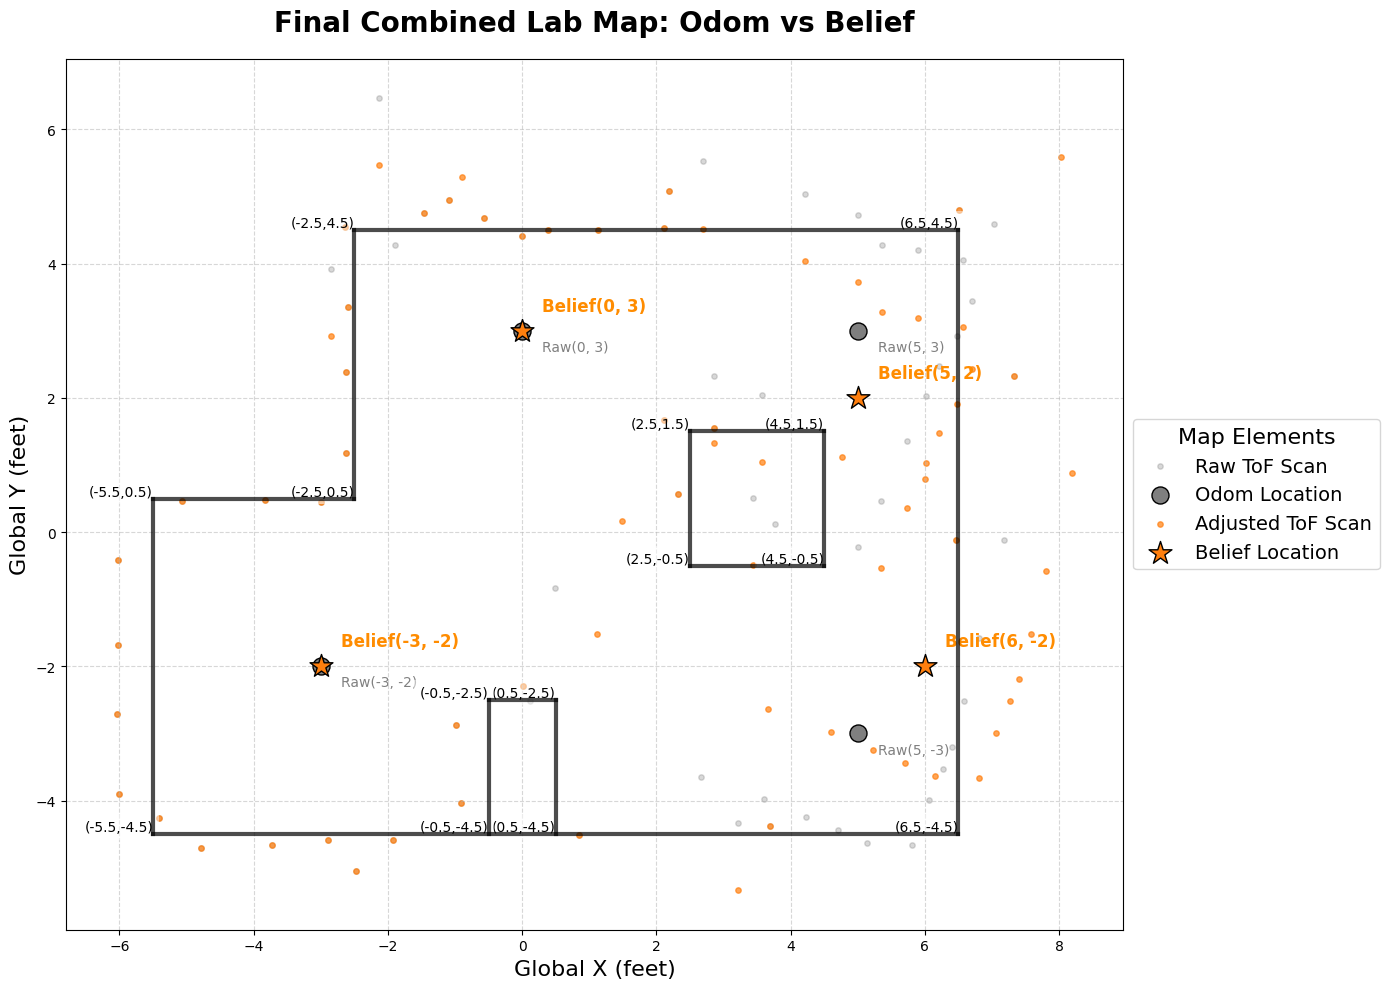

Traceback (most recent call last):
  File "/Users/y1hhnn/Desktop/ECE4160/FastRobots-sim-release/src/plotter.py", line 252, in closeEvent
    result = QtGui.QMessageBox.question(self,
             ^^^^^^^^^^^^^^^^^
AttributeError: module 'pyqtgraph.Qt.QtGui' has no attribute 'QMessageBox'


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 核心方法：将传感器原始数据转为全局 XY 坐标
# ==========================================
def get_global_coords(yaw_values, tof_values, robot_x, robot_y, angle_offset=0.0):
    """
    yaw_values: 原始陀螺仪角度数组
    tof_values: 原始 ToF 距离数组 (mm)
    robot_x, robot_y: 机器人当前所在的全局坐标 (feet)
    angle_offset: 传感器的安装朝向偏移 (ToF2=0度, ToF1=270度)
    """
    # 1. 解包并对齐连续航向角
    yaw_unwrapped = np.degrees(np.unwrap(np.radians(yaw_values)))
    yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]

    # 2. 提取有效数据并转成英尺 (1 foot = 304.8 mm)
    valid_mask = (tof_values > 0) & (tof_values < 6000)
    valid_yaw = yaw_continuous[valid_mask]
    valid_dist_ft = tof_values[valid_mask] / 304.8

    # 3. 加上传感器的物理安装角度偏移
    angles_rad = np.radians(valid_yaw + angle_offset)

    # 4. 局部极坐标 -> 全局笛卡尔坐标
    # 0度是+Y轴，且逆时针角度增加 -> X = -sin(theta), Y = cos(theta)
    x_global = robot_x + valid_dist_ft * np.sin(-angles_rad)
    y_global = robot_y + valid_dist_ft * np.cos(angles_rad)

    return x_global, y_global

# ==========================================
# 准备数据与画布
# ==========================================

raw_locations = [ (5,-3), (5,3), (-3,-2), (0,3)]
raw_colors = ['tab:grey', 'tab:grey', 'tab:grey', 'tab:grey', 'tab:grey']

belief_locations = [ (6,-2), (5,2), (-3,-2), (0,3)]
belief_colors = ['tab:orange', 'tab:orange', 'tab:orange', 'tab:orange', 'tab:orange']

# 加载数据
datasets = [
    np.load("../data/sensor_data_5_-3_6_-2.npz"),
    np.load("../data/sensor_data_5_3_5_2.npz"),
    np.load("../data/sensor_data_-3_-2_-3_-2.npz"),
    np.load("../data/sensor_data_0_3_0_3.npz")
]

# Ground truth lines (单位: meters)
ground_truth_lines_meters = [
    [(-1.6764,0.1524), (-1.6764,-1.3716)],
    [(-1.6764,-1.3716), (1.9812,-1.3716)],
    [(1.9812,-1.3716), (1.9812,1.3716)],
    [(1.9812,1.3716), (-0.7620,1.3716)],
    [(-0.7620,1.3716), (-0.7620,0.1524)],
    [(-0.7620,0.1524), (-1.6764,0.1524)],
    [(0.7620,-0.1524), (1.3716,-0.1524)],
    [(1.3716,-0.1524), (1.3716,0.4572)],
    [(1.3716,0.4572), (0.7620,0.4572)],
    [(0.7620,0.4572), (0.7620,-0.1524)],
    [(-0.1524,-1.3716), (-0.1524,-0.7620)],
    [(-0.1524,-0.7620), (0.1524,-0.7620)],
    [(0.1524,-0.7620), (0.1524,-1.3716)]
]

# ==========================================
# 遍历每个站立点，计算坐标并画图
# ==========================================
plt.figure(figsize=(14, 10))

for i, (raw_loc, bel_loc, data) in enumerate(zip(raw_locations, belief_locations, datasets)):
    raw_x, raw_y = raw_loc
    bel_x, bel_y = bel_loc
    
    r_color = raw_colors[i]
    b_color = belief_colors[i]
    
    # 提取 npz 里面的数组
    yaw = data['yaw_values']
    tof1 = data['tof_1_values']
    tof2 = data['tof_2_values']

    valid_index = (tof2 > 0) & (tof2 < 6000)
    yaw = yaw[valid_index]
    tof1 = tof1[valid_index]
    tof2 = tof2[valid_index]
    yaw =yaw[:18]
    tof1 = tof1[:18]
    tof2 = tof2[:18]
    
    # 补偿传感器物理偏移
    tof1 = np.where(tof1 == -1, 0, tof1 + 31.75)
    tof2 = np.where(tof2 == -1, 0, tof2 + 69.85)
    
    # ----------------------------------------------------
    # 1. 计算并画出 Raw Location (Odom) 的点云
    # ----------------------------------------------------
    raw_x2, raw_y2 = get_global_coords(yaw, tof2, raw_x, raw_y, angle_offset=0.0)
    # raw_x1, raw_y1 = get_global_coords(yaw, tof1, raw_x, raw_y, angle_offset=270.0)
    
    # 为了防止灰色的原始点云太抢眼，设置 alpha=0.3
    label_raw = 'Raw ToF Scan' if i == 0 else ""
    plt.scatter(raw_x2, raw_y2, s=15, color=r_color, alpha=0.3, label=label_raw)
    # plt.scatter(raw_x1, raw_y1, s=15, color=r_color, alpha=0.3)
    
    # 标出 Raw Robot 站立点 (用圆形表示)
    label_raw_loc = 'Odom Location' if i == 0 else ""
    plt.scatter(raw_x, raw_y, marker='o', s=150, color=r_color, edgecolors='black', zorder=5, label=label_raw_loc)
    plt.text(raw_x + 0.3, raw_y - 0.3, f'Raw({raw_x}, {raw_y})', fontsize=10, color='grey')

    # ----------------------------------------------------
    # 2. 计算并画出 Belief Location (Adjusted) 的点云
    # ----------------------------------------------------
    bel_x2, bel_y2 = get_global_coords(yaw, tof2, bel_x, bel_y, angle_offset=0.0)
    # bel_x1, bel_y1 = get_global_coords(yaw, tof1, bel_x, bel_y, angle_offset=270.0)
    
    # Belief 校正后的点云用亮橙色，alpha=0.7 显得更清晰
    label_bel = 'Adjusted ToF Scan' if i == 0 else ""
    plt.scatter(bel_x2, bel_y2, s=15, color=b_color, alpha=0.7, label=label_bel)
    # plt.scatter(bel_x1, bel_y1, s=15, color=b_color, alpha=0.7)
    
    # 标出 Belief Robot 站立点 (用巨大星星表示)
    label_bel_loc = 'Belief Location' if i == 0 else ""
    plt.scatter(bel_x, bel_y, marker='*', s=300, color=b_color, edgecolors='black', zorder=6, label=label_bel_loc)
    plt.text(bel_x + 0.3, bel_y + 0.3, f'Belief({bel_x}, {bel_y})', fontsize=12, fontweight='bold', color='darkorange')


# ==========================================
# 画出地图边界 (并自动将 Meters 转换为 Feet)
# ==========================================
vertices = set()
M_TO_FT = 1 / 0.3048 # 转换系数

for line in ground_truth_lines_meters:
    # 提取坐标并转换为英尺
    x1 = line[0][0] * M_TO_FT
    y1 = line[0][1] * M_TO_FT
    x2 = line[1][0] * M_TO_FT
    y2 = line[1][1] * M_TO_FT
    
    plt.plot([x1, x2], [y1, y2], color='black', alpha=0.7, linewidth=3, linestyle='-', zorder=10)
    
    # 记录转换后的顶点用于添加文字标签
    vertices.add((x1, y1))
    vertices.add((x2, y2))

# 统一画顶点 (以英尺显示)
for (x, y) in vertices:
    plt.text(x, y,
             f'({x:.1f},{y:.1f})',
             fontsize=10,
             ha='right',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    
# ==========================================
# 图表美化
# ==========================================
plt.title('Final Combined Lab Map: Odom vs Belief', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Global X (feet)', fontsize=16)
plt.ylabel('Global Y (feet)', fontsize=16)
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.5)

# 把图例放到图外
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14, title="Map Elements", title_fontsize=16)

plt.tight_layout()
plt.show()